# H5 — Estacionalidad marcada y alargamiento del verano

Analizamos si el patrón estacional de temperatura está cambiando: ¿Se están alargando los veranos? ¿Está aumentando la amplitud térmica entre invierno y verano? ¿El cambio es igual en costa e interior?

## 1. Imports y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.variables import CIUDADES, crear_dirs
from scripts.funciones_variables import cargar_datos
from scripts.analisis import estacionalidad, verano_meteorologico
from scripts.graficos import graficos_estacionalidad, graficos_verano

crear_dirs()
cargar_datos()

📂 Cargando datos...
  ✅ bilbo: 31,412 filas
  ✅ donostia: 31,412 filas
  ✅ gasteiz: 31,412 filas
  ✅ iruna: 31,412 filas
  ✅ baiona: 31,412 filas
  ✅ arrasate: 31,412 filas
  ✅ maule: 31,412 filas



## 2. Ciclo anual por quinquenios

Temperatura media mensual agrupada en períodos de 5 años. El gradiente de colores va de frío (décadas antiguas) a cálido (recientes). Si las líneas recientes están por encima en verano pero no en invierno, indica que la amplitud térmica está aumentando.

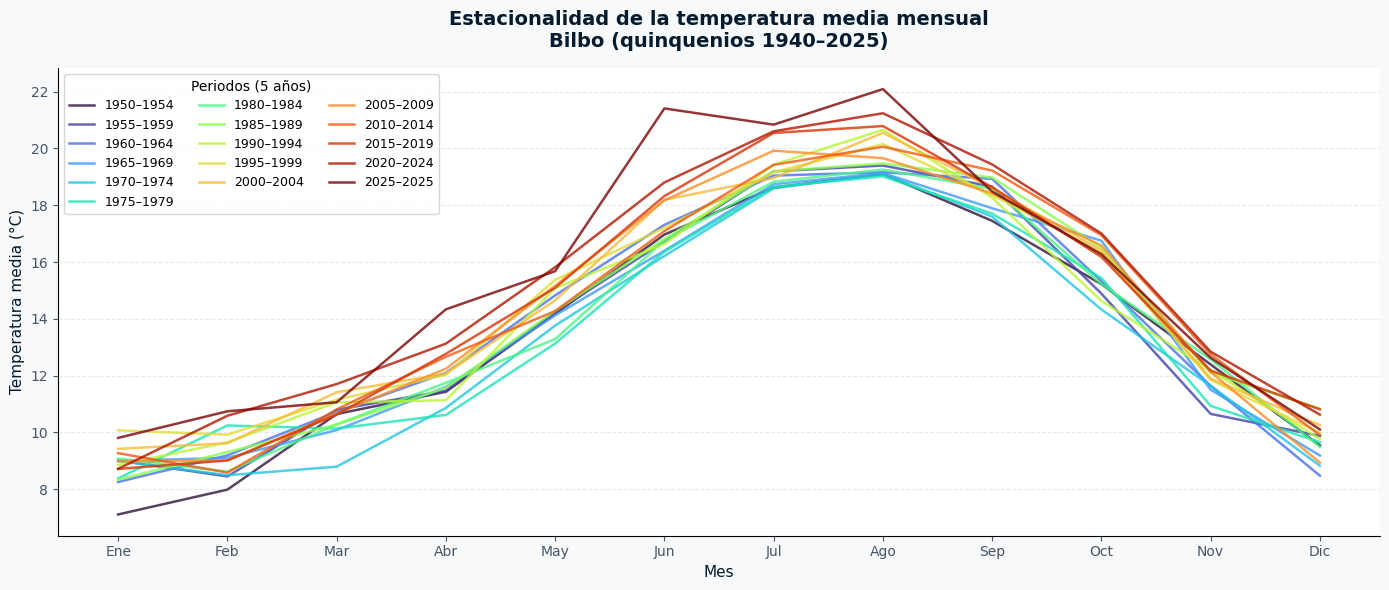

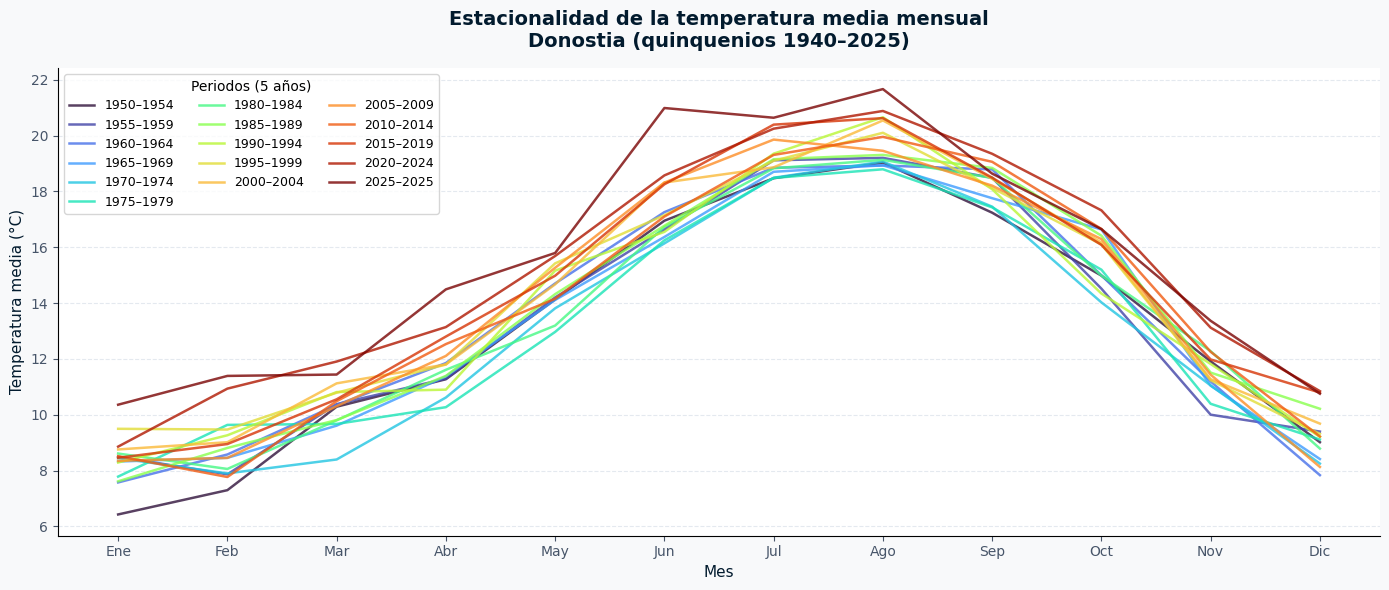

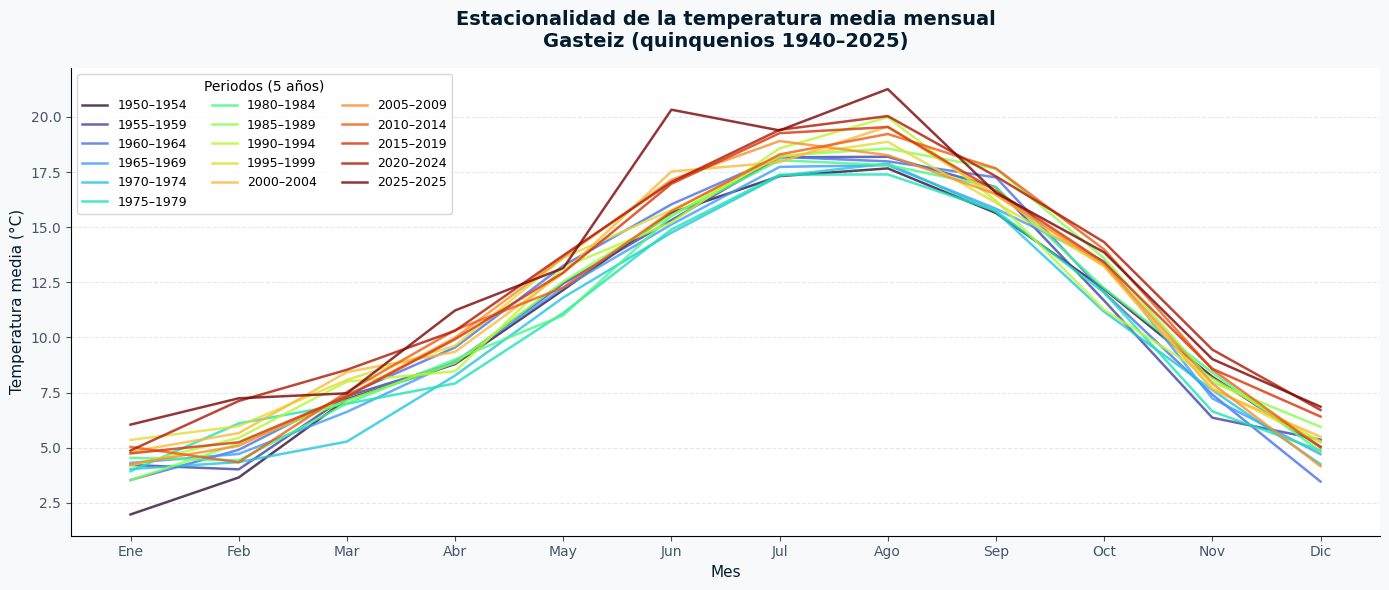

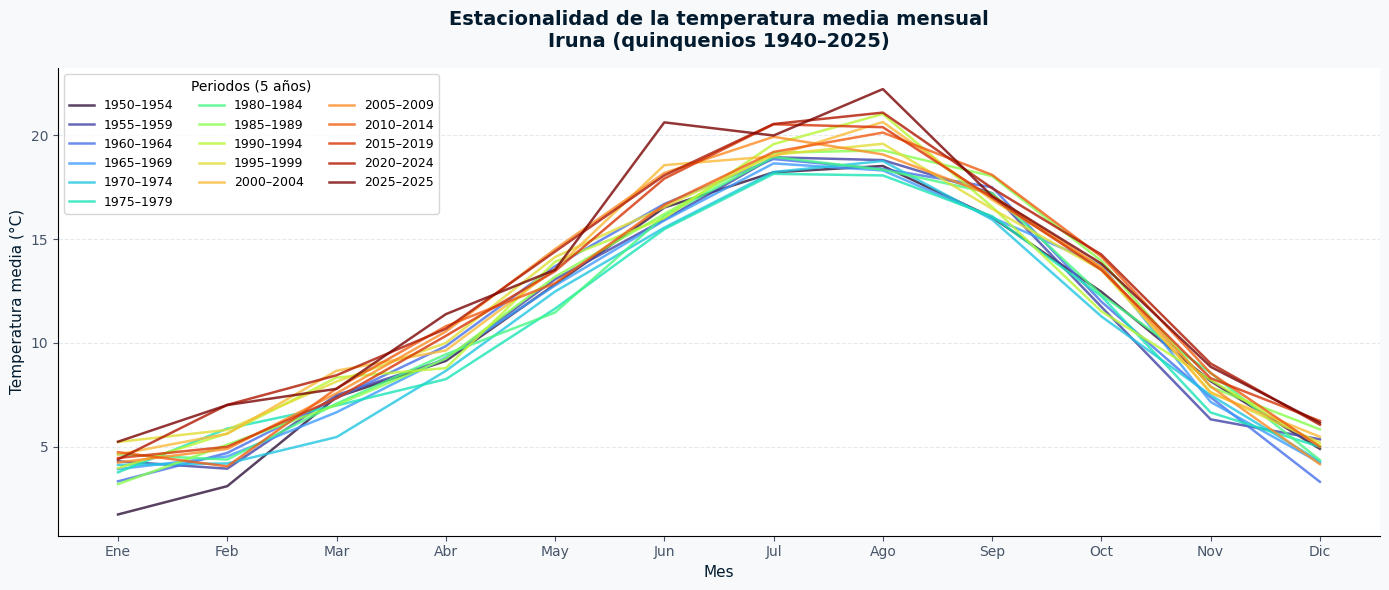

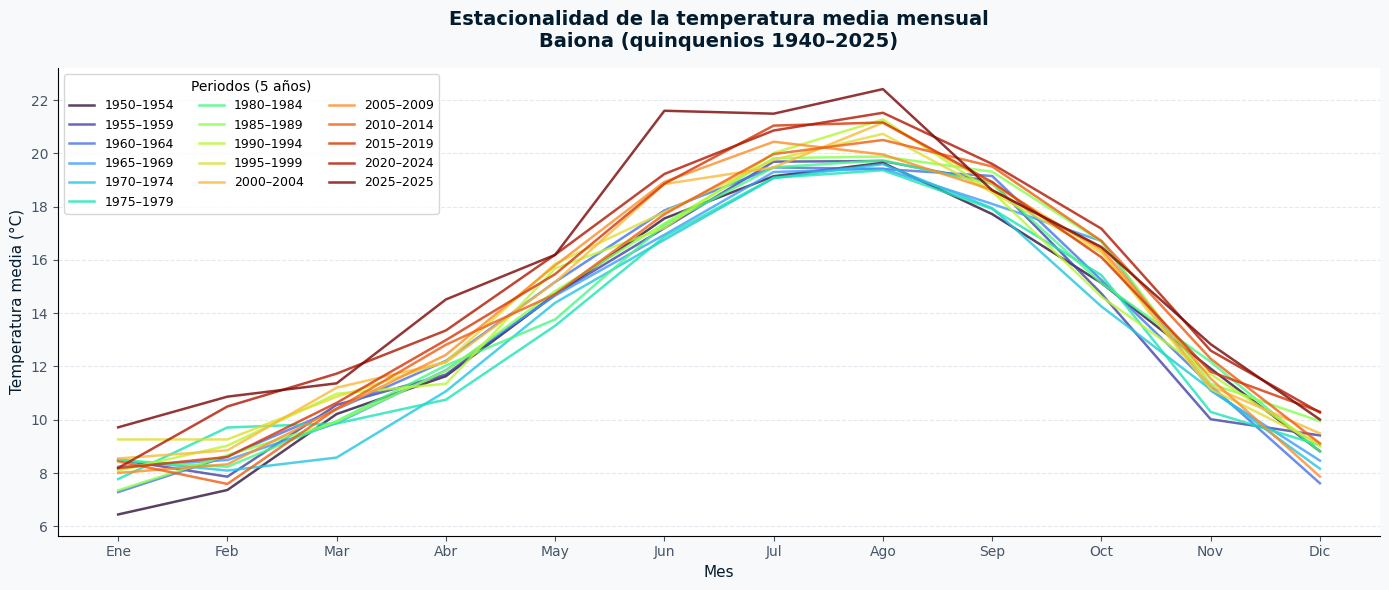

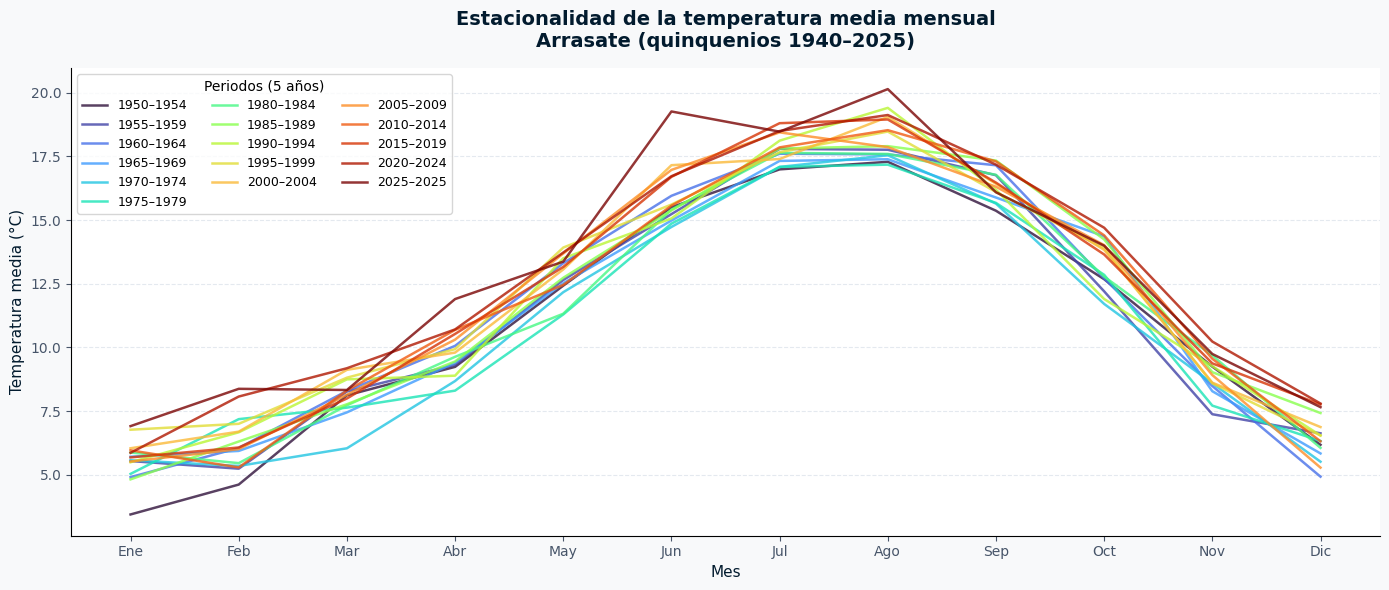

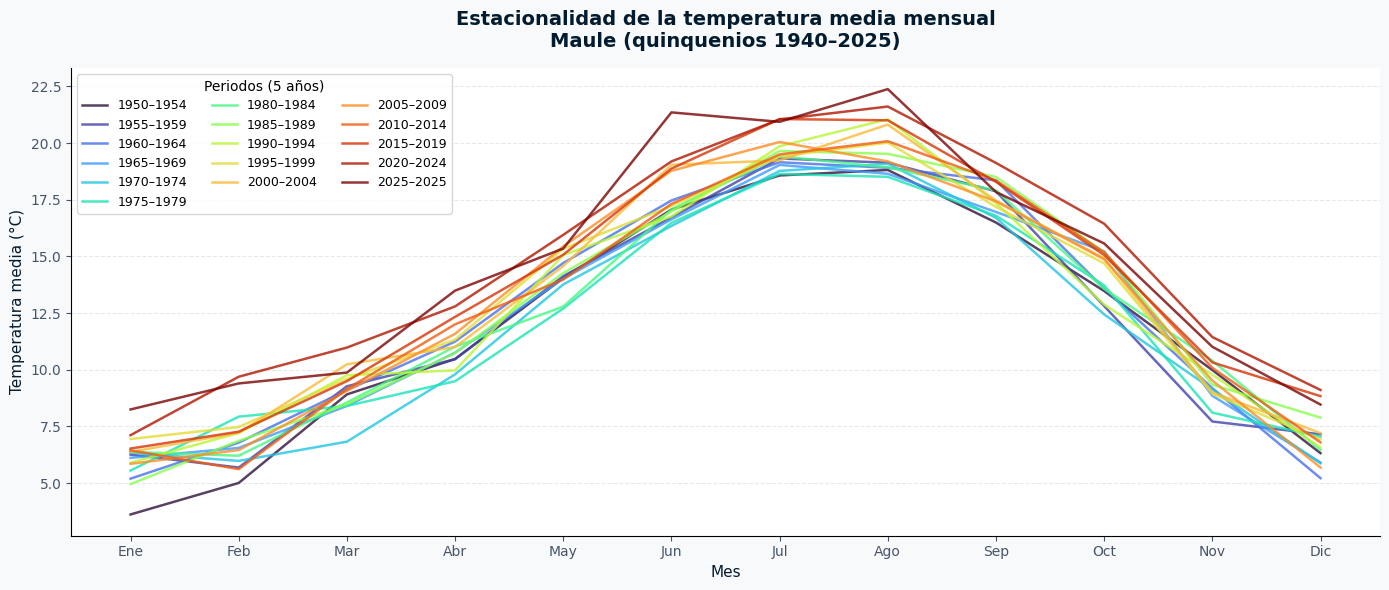

In [2]:
datos_estac = estacionalidad.calcular_todos()
graficos_estacionalidad.graficar_estacionalidad(datos_estac['estacionalidad'])

## 3. Evolución de la amplitud térmica estacional

Diferencia entre la temperatura media de julio y enero por quinquenio. Una tendencia creciente indica que los veranos se calientan más rápido que los inviernos, marcando más la estacionalidad.

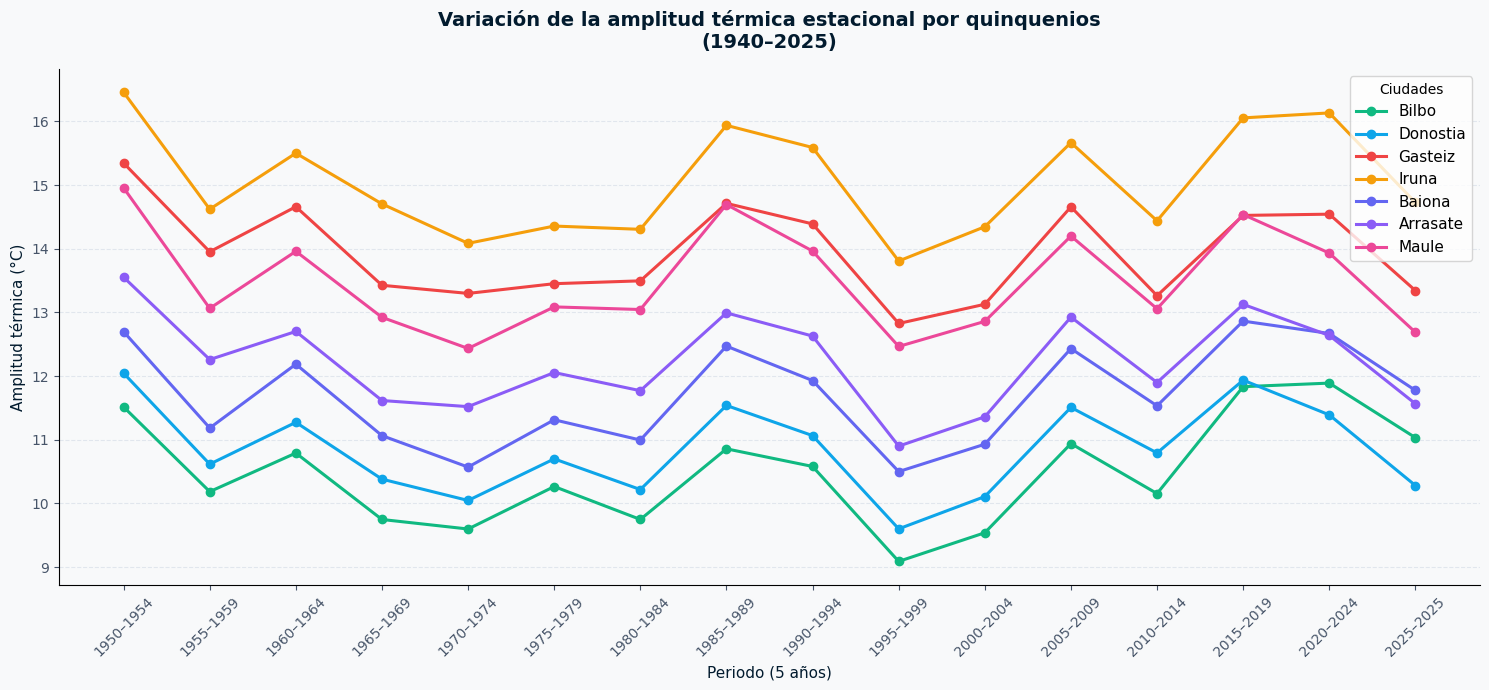

In [3]:
graficos_estacionalidad.graficar_amplitud_termica(datos_estac['amplitud'])

## 4. Longitud del verano meteorológico

Definimos el **verano meteorológico** como la racha más larga de días consecutivos con temperatura media > 20°C. La tendencia positiva indica que los veranos se están alargando.

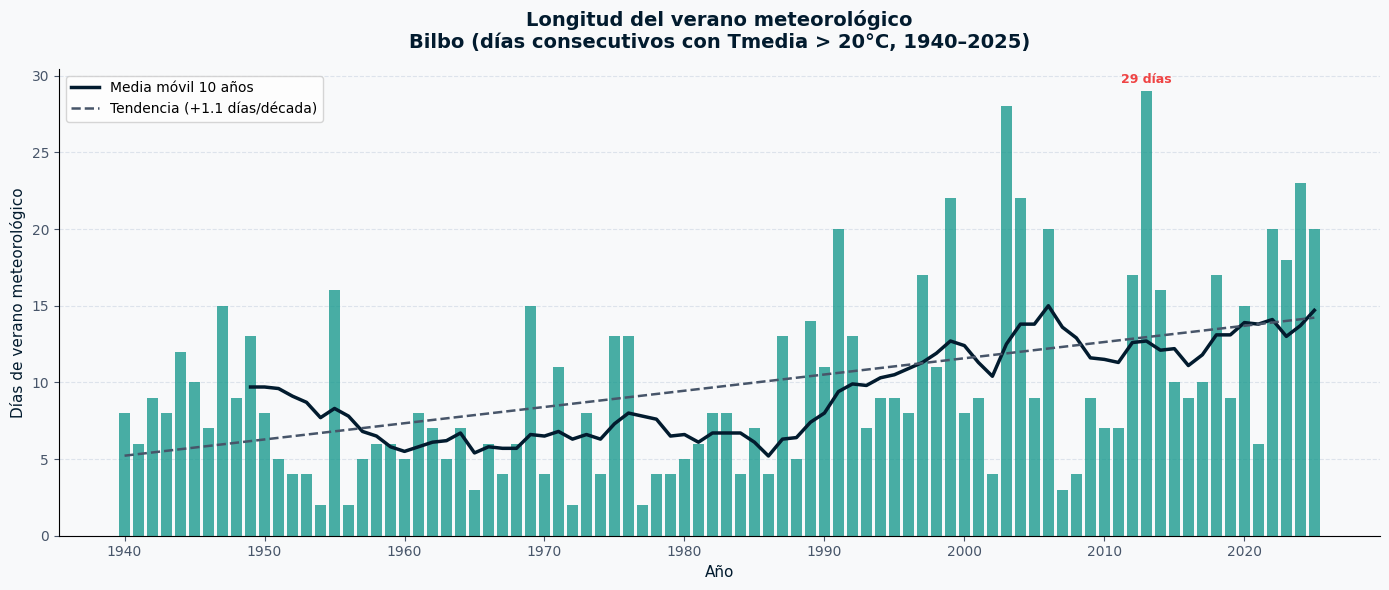

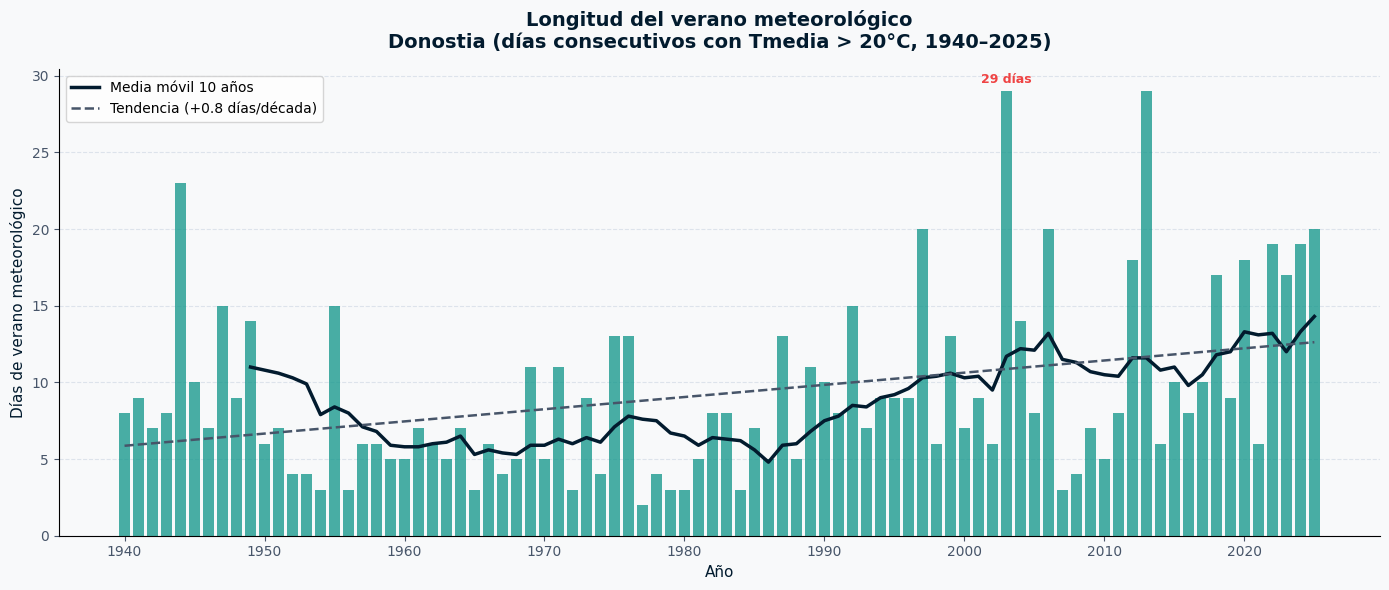

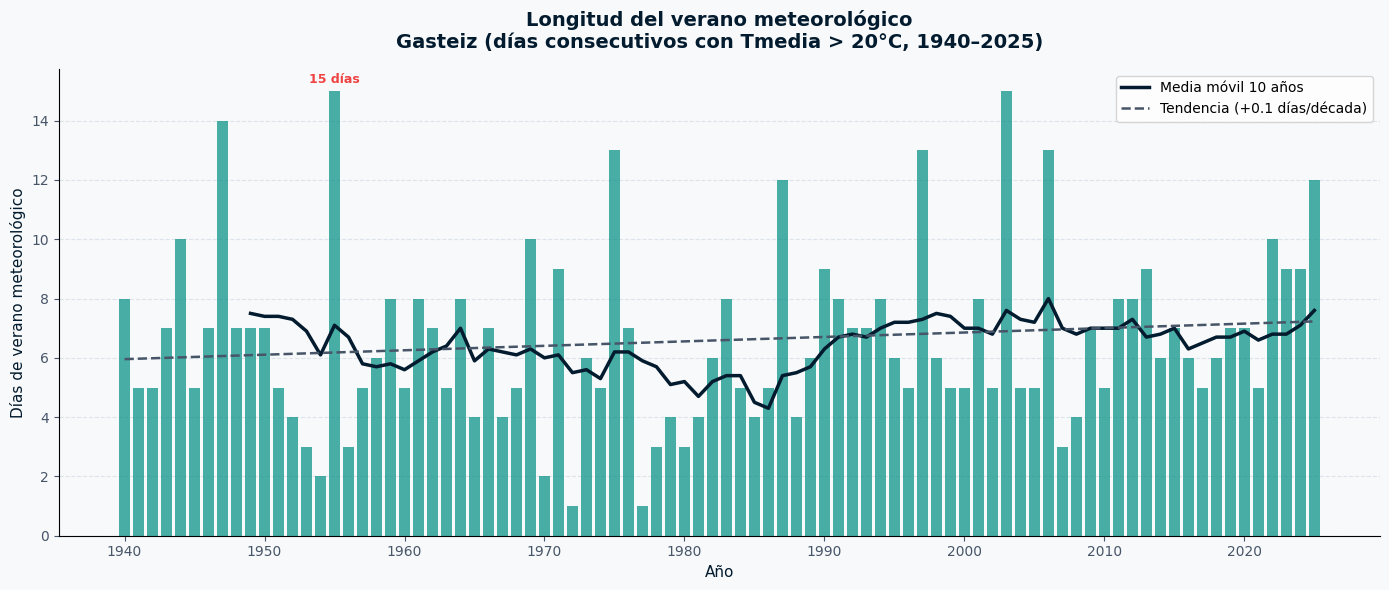

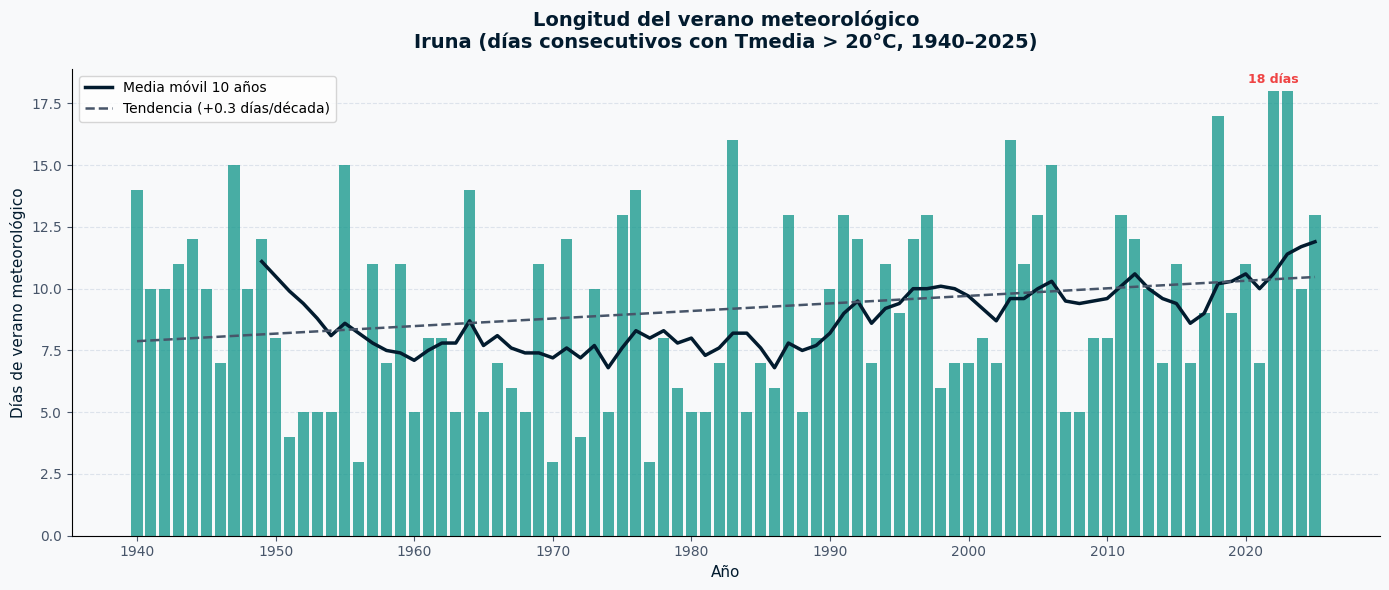

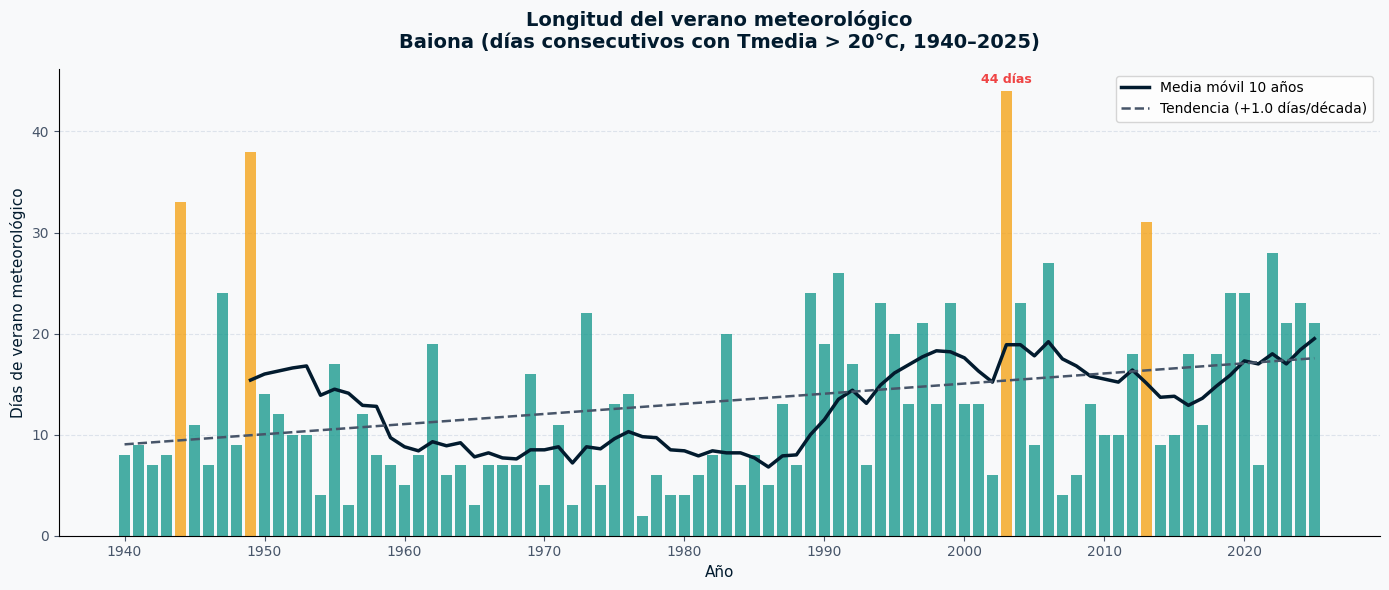

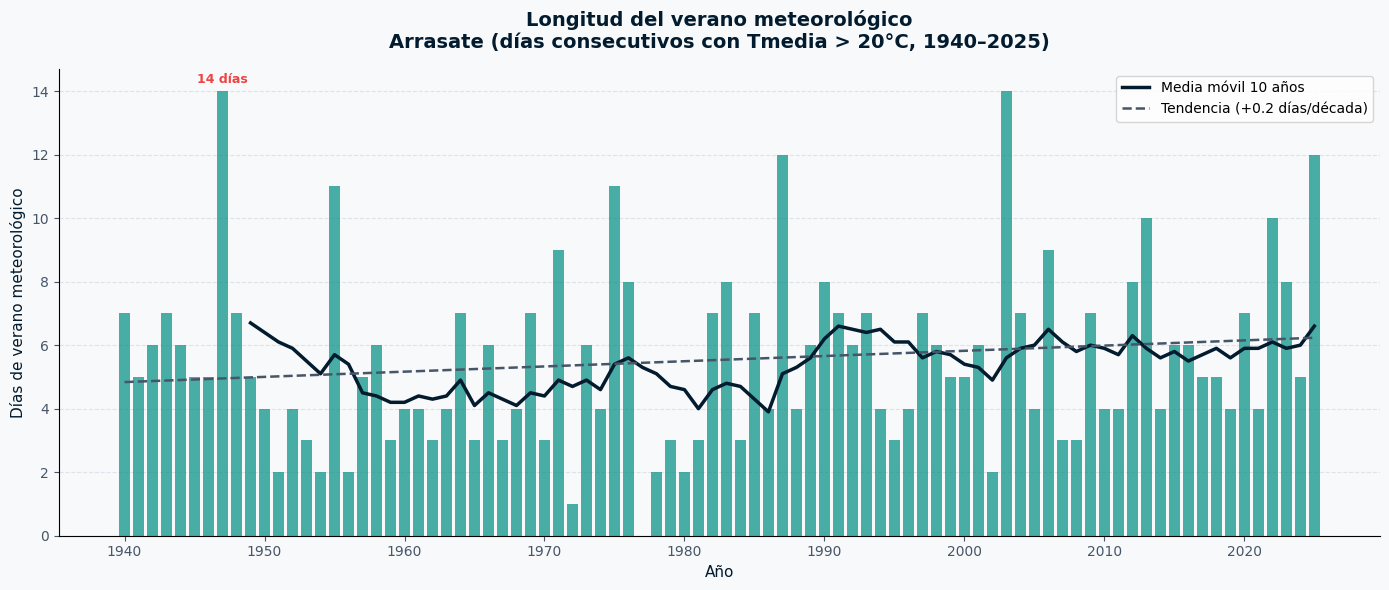

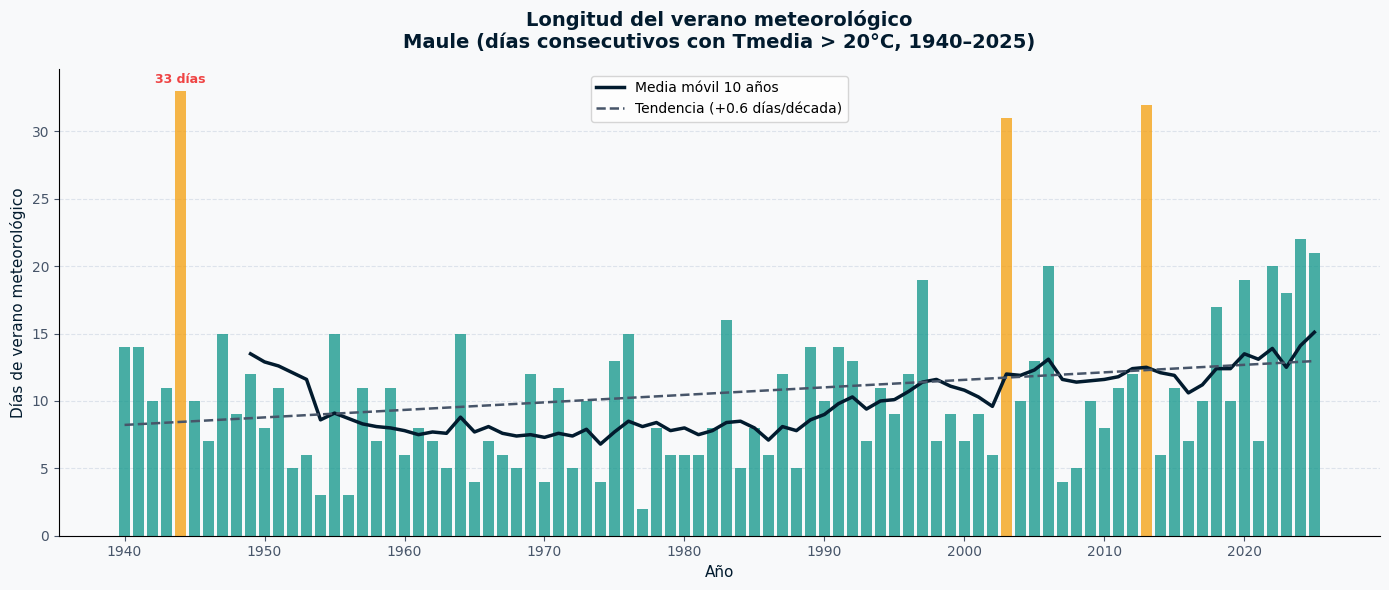

In [4]:
datos_verano = verano_meteorologico.calcular_todos()
graficos_verano.graficar_longitud_verano(datos_verano)

## 5. Comparativa del verano entre ciudades

Medias móviles de la longitud del verano para todas las ciudades. Esperamos que las ciudades del interior (Gasteiz, Iruña) muestren veranos más largos y con mayor tendencia de crecimiento.

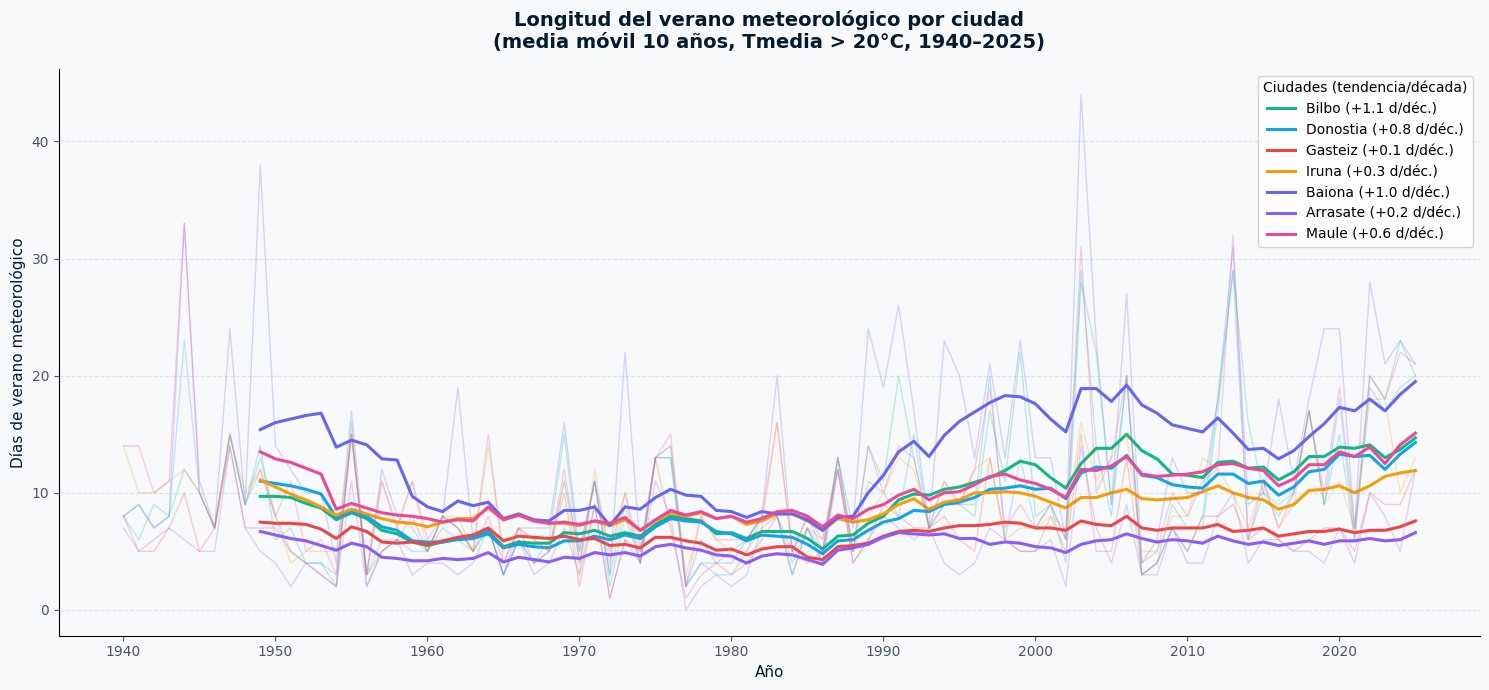

In [5]:
graficos_verano.graficar_verano_comparativa(datos_verano)

## 6. Distribución de la longitud del verano por décadas (boxplot)

Vemos cómo cambia no solo la media sino toda la distribución. Décadas recientes con boxplots desplazados hacia arriba y más compactos indican veranos más largos y predecibles.

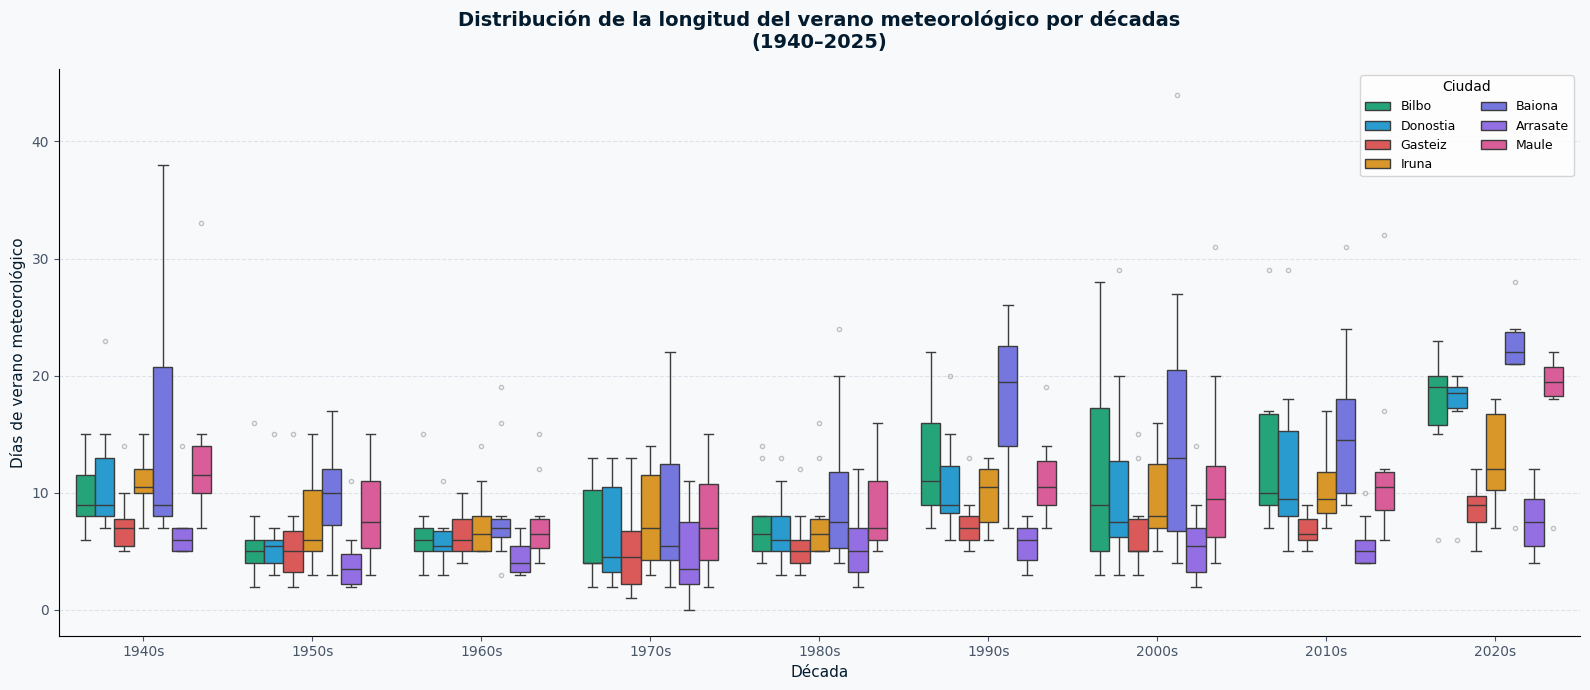

In [6]:
graficos_verano.graficar_boxplot_verano_decadas(CIUDADES)

## 7. Resumen estadístico

In [7]:
import pandas as pd

rows = []
for r in datos_verano:
    ciudad = r['ciudad']
    import numpy as np
    dias = np.array(r['dias'])
    años = r['años']
    media_reciente = dias[np.array(años) >= 2000].mean()
    media_historica = dias[np.array(años) < 1970].mean()
    rows.append({
        'Ciudad':                  ciudad.nombre.capitalize(),
        'Dist. mar (km)':          ciudad.dist_mar,
        'Media 1940–1969 (días)':  round(media_historica, 1),
        'Media 2000–2025 (días)':  round(media_reciente, 1),
        'Cambio (días)':           round(media_reciente - media_historica, 1),
        'Tendencia (días/década)': round(r['slope'] * 10, 1),
    })

resumen = pd.DataFrame(rows).sort_values('Cambio (días)', ascending=False)
display(resumen.style.background_gradient(subset=['Cambio (días)', 'Tendencia (días/década)'], cmap='YlOrRd'))

,Ciudad,Dist. mar (km),Media 1940–1969 (días),Media 2000–2025 (días),Cambio (días),Tendencia (días/década)
0,Bilbo,11.100000,7.400000,13.400000,6.100000,1.100000
4,Baiona,1.500000,11.200000,17.000000,5.800000,1.000000
1,Donostia,0.000000,7.600000,12.500000,4.900000,0.800000
6,Maule,25.200000,9.700000,13.300000,3.600000,0.600000
3,Iruna,61.800000,8.600000,10.600000,1.900000,0.300000
5,Arrasate,33.200000,5.100000,6.200000,1.100000,0.200000
2,Gasteiz,58.200000,6.500000,7.300000,0.700000,0.100000
